## STEP 2: MODELO HEPATITIS B 1D MÁS REALISTA

## Introducción al método de las diferencias finitas


### Derivadas discretas (aproximadas)

La aproximación por diferencias finitas es el más antiguo de los métodos aplicados para obtener soluciones numéricas de ecuaciones diferenciales. La primera utilización de este método se atribuye a Leonhard Euler en 1768. La idea de los métodos de diferencias finitas es en realidad bastante simple, ya que corresponde a una estimación de una derivada mediante la diferencia discreta del valor de la función en dos puntos cercanos.

La derivada de una función $u(x)$ en $x$ se define como:

$$
	\frac{\partial u }{\partial x} = \lim_{\Delta x \rightarrow 0} \frac{u(x+\Delta x) - u(x)}{\Delta x} \,.
$$


Si quitamos el límite de $\Delta x \rightarrow 0$ en la expresión anterior, considerando un $\Delta x$ finito, entonces obtendremos el concepto de derivada discreta como una diferencia finita. Ésta se calculará como el ratio de la diferencia de la función evaluada en $x+\Delta x$ y $x$ respecto de $\Delta x$.

En el caso de utilizar una diferencia finita, se cometerá cierto error y éste se puede derivar utilizando una expansión en serie de Taylor:

$$
u(x+\Delta x )=u(x)+\left(\frac{\partial u}{\partial x}\right)\Delta x+\left(\frac{\partial^2 u}{\partial x^2}\right)\frac{\Delta x^2}{2} +\left(\frac{\partial^3 u}{\partial x^3}\right)\frac{\Delta x^3}{6} + ...\,\,,
$$

Despejando la primera derivada de la expresión anterior obtenemos:


$$
\frac{\partial u}{\partial x}
= \frac{u(x+\Delta x) - u(x)}{\Delta x}
- \underbrace{
\left(\frac{\partial^2 u}{\partial x^2}\right)\frac{\Delta x}{2}
+ \left(\frac{\partial^3 u}{\partial x^3}\right)\frac{\Delta x^2}{6}
+ \cdots
}_{\text{error de truncamiento}}
$$


lo que permite expresar la aproximación de la primera derivada como:

$$
	\frac{\partial u }{\partial x} \approx  \frac{u(x+\Delta x) - u(x)}{\Delta x}  \, .
$$

En 1D, vamos a considerar un dominio espacial $[0,L]$ que se discretizará en $N=L/\Delta x+1$ nodos localizados en las coordenadas $x_i=i\Delta x$, con $\Delta x$ el paso de discretización espacial. En los puntos de la malla, se aproximarán las variables como $u_i \approx u(x_i)$


Generalmente, se usan dos tipos de aproximación de las derivadas espaciales en función de qué información cojamos:

- Diferencias regresivas (hacia atrás):

$$
	\frac{\partial u }{\partial x} \approx  \frac{u_{i} - u_{i-1}}{\Delta x}  \, .
$$

- Diferencias progresivas (hacia adelante):


$$
	\frac{\partial u }{\partial x} \approx  \frac{u_{i+1} - u_{i}}{\Delta x}  \, .
$$

En el caso de tener que aproximar una derivada segunda, podemos combinar ambas para obtener:

$$
	\frac{\partial ^2 u }{\partial x^2} \approx  \frac{\frac{u_{i+1} - u_{i}}{\Delta x} - \frac{u_{i} - u_{i-1}}{\Delta x}}{\Delta x} = \frac{u_{i+1} -2u_{i} +u_{i-1}}{\Delta x^2} \, .
$$

### 1. Importamos librerías

In [25]:
import numpy as np              # Librería para cálculo numérico
import math                     # Librería para utilizar símbolos matemáticos como el número pi, que se escribe como math.pi
from scipy import special
import matplotlib.pyplot as plt # Librería para poder dibujar gráficas
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

### 2. Damos valor a las constantes

In [26]:
# Constantes
a1 = 1.0                # desintegración natural del virus (q1)
C1 = 1.0                # capacidad de q1 (virus)
epsilon = 0.05          # parámetro efecto Allee
kappa = 0.01            # parámetro efecto Allee
a5 = 0.08               # efectividad de las células T 
a2h = 2.0               # regula la entrada de células Th a través del "portal field" en función del virus (q1) total en un tiempo t
Cth = 8.0               # capacidad de Th
a6h = 0.2              # tasa de decaimiento Th
a6c = 0.2               # tasa de decaimiento Tc
Ctc = 15.0              # capacidad de Tc
a3 = 0.8                # producción de citoquinas (q3), por el virus y las células Th
a_nd = 0.6              # contante de desintegración de las citoquinas (q3)
a2c = 2.0               # regula la entrada de células Tc

### 3. Programamos ecuaciones

#### **ECUACIONES DE REACCIÓN**

##### 1. Definimos sistemas intermedios (funciones f)

In [27]:
def f1M1(q1):
    return a1*q1*(C1-q1)*((q1-epsilon)/(q1+kappa))

def f1M5(q1,Tc):
    return -a5*q1*Tc

def fthM2(q1_integral,Th,xi):
    return a2h*(Cth-Th)*xi*q1_integral  #a2h*(Cth-Th)*xi*q1_integral

def fthM6(q1,Th):
    return -a6h*Th*(C1-q1)

def ftcM2(q1_integral,Tc,xi):
    return a2c*(Ctc-Tc)*xi*q1_integral   #a2c*(Ctc-Tc)*xi*q1_integral

def ftcM6(q1,Tc):
    return -a6c*Tc*(C1-q1)

def f3M3(q1,Th,q3):
    return a3*Th*q1-a_nd*q3

##### 2. Definimos ecuaciones finales de reacción

In [28]:
def R_q1(q1,Tc):
    return f1M1(q1) + f1M5(q1,Tc)          # virus (q1)

def R_Th(q1,Th,xi,q1_integral):
    return fthM2(q1_integral,Th,xi) + fthM6(q1,Th)     # células T helper (Th)

def R_Tc(q1,Tc,xi,q1_integral):
    return ftcM2(q1_integral,Tc,xi) + ftcM6(q1,Tc)     # células T cytotoxic (Tc)

def R_q3(q1,Th,q3):
    return f3M3(q1,Th,q3)                  # citoquinas (q3)

#### **ECUACIONES DE DIFUSIÓN**

Podría haberse programado así también:

```python
def diff_q1(d1,dx,q1):
    return d1 * (q1[2:]-2*q1[1:-1]+q1[:-2])/dx**2       # virus (q1)

def diff_Th(dTh,dx,Th):
    return dTh * (Th[2:]-2*Th[1:-1]+Th[:-2])/dx**2      # células T helper (Th)

def diff_q3(d3,dx,q3):
    return d3 * (q3[2:]-2*q3[1:-1]+q3[:-2])/dx**2       # citoquinas (q3)

```

In [29]:
# u = q1, Th, Tc, q3 (ahora es un array ya no es un escalar)
# d = d1, dTh, dTc, d3 (coeficientes de difusión para cada reacción)
# sería de forma general => diff(d,dx,u)

def diff_u(d,dx,u):
    dp=0.5*(d[2:]+d[1:-1]) #promedio lado derecho (p)
    dm=0.5*(d[1:-1]+d[:-2]) #promedio lado izq (m)
    return (dp*(u[2:]-u[1:-1]) - dm*(u[1:-1]-u[:-2]))/dx**2

#### **ECUACIONES DE ADVECCIÓN**

En esta parte, el movimiento de las células Tc está dominado pro advección, es decir, las celulas Tc siguen el gradiente de las citoquinas.

In [30]:
def adv_Tc(dTc,dx,Tc,q3):    # termino chemotaxis adveccion

    vp=dTc[1:-1]*(q3[2:]-q3[1:-1])/dx
    vm=dTc[1:-1]*(q3[1:-1]-q3[:-2])/dx

    fp=np.maximum(vp,0)*Tc[1:-1] + np.minimum(vp,0)*Tc[2:]
    fm=np.maximum(vm,0)*Tc[:-2] + np.minimum(vm,0)*Tc[1:-1]

    vmax = max(np.max(np.abs(vp)), np.max(np.abs(vm)), 1e-14)

    return ( fp-fm )/dx,vmax      # células T cytotoxic (Tc)

### 4. Sistema completo advección-reacción-difusión (Modelo 1)

#### Codigo vectorizado


En lugar de usar un bucle:

```python
for i in range(1, N-1):
    T[n+1, i] = T[n, i] + b * dt / dx**2 * (T[n, i+1] + T[n, i-1] - 2*T[n, i])
```

se utiliza una operación **vectorizada** que calcula todos los puntos internos simultáneamente:

```python
T[n, 2:]   →  [T[n, 2], T[n, 3], ..., T[n, N-1]]   →  T[n, i+1]
T[n, :-2]  →  [T[n, 0], T[n, 1], ..., T[n, N-3]]   →  T[n, i-1]
T[n, 1:-1] →  [T[n, 1], T[n, 2], ..., T[n, N-2]]   →  T[n, i]
```

Todas estas porciones (`T[n, 2:]`, `T[n, :-2]`, `T[n, 1:-1]`) tienen el mismo tamaño (`N - 2` elementos) y corresponden a los **nodos interiores** del dominio, es decir, todos menos los extremos donde se aplican las condiciones de contorno.

De este modo, la expresión:

```python
T[n, 2:] + T[n, :-2] - 2 * T[n, 1:-1]
```

calcula **para todos los nodos interiores a la vez** el numerador de la fórmula de diferencias finitas para la segunda derivada espacial:

$$ T_{i+1} - 2T_i + T_{i-1} $$


In [31]:
# Parámetros del problema
L = 1.0             # Longitud del dominio en x
N = 21              # Número de nodos espaciales en x
dx = L / (N - 1)    # 0.05 => artículo, pero es inferior al que se obtiene con la fórmula !!!!!!!!!!!!!
tf = 50             # Tiempo final
sigma = 0.4         # Parámetro de estabilidad
U0 = 0.1            # valor entre epsilon<U0<C1 => 0.05<U0<1, no se usa

# Valores de los coeficientes de disfusión
valor_d1 = 0.01    # valor original 0.6
valor_dTh = 0.5   # valor original 0.9
valor_dTc = 0.1   # valor original 0.5
valor_d3 = 0.06    # valor original 0.5

# Vectores de los coeficientes de difusión
d1 = np.full(N, valor_d1)
dTh = np.full(N, valor_dTh)
dTc = np.full(N, valor_dTc)
d3 = np.full(N, valor_d3)

# Paso de tiempo y número de pasos
dt1 = (sigma * dx**2 / d1).min()
dtTh = (sigma * dx**2 / dTh).min()
dtTc = (sigma * dx / dTc).min()
dt3 = (sigma * dx**2 / d3).min()

dt = min(dt1, dtTh, dtTc, dt3)
nt = int(tf / dt)

print(f"La longitud del dominio es: {L}")
print(f"El número de nodos espaciales es: {N}")
print(f"El tamaño del paso espacial es: {dx}")
print(f"El número de pasos temporales es: {nt}")
print(f"El paso de tiempo es: {dt}")
print(f"El tiempo final es: {(nt - 1) * dt}\n")

# Vectores espaciales y temporales
x = np.linspace(0, L, N)
t = np.linspace(0, (nt - 1) * dt, nt)

# Region inflow
lin = 0.1 # zona pequeña de entrada del virus (tamaño puerta)
xi = np.where(x <= lin, 1.0, 0.0) # máscara para que solo empiece el virus en una zona pequeña de L
count = np.sum(xi == 1)
xi=xi/(count*dx) # normalizamos

print(xi,count)

# Inicialización de la matriz de cada variable
q1 = np.zeros((nt, N))
Th = np.zeros((nt, N))
Tc = np.zeros((nt, N))
q3 = np.zeros((nt, N))

# Condición incial para cada variable (valor constante, sacada del artículo)
q1_0 = 0.1 # cantidad inicial de virus (de 0-0.05, el virus se elimina completamente al ser < epsilon)
Th_0 = 0.0 # cantidad inicial Th
Tc_0 = 0.0 # cantidad inicial Tc
q3_0 = 0.0 # cantidad inicial de citoquinas

q1[0, :] = q1_0*np.ones_like(x) #gaussian_initial_condition(x,L,U0,sigma)
Th[0, :] = Th_0*np.ones_like(x) #gaussian_initial_condition(x,L,U0,sigma)
Tc[0, :] = Tc_0*np.ones_like(x) #gaussian_initial_condition(x,L,U0,sigma)
q3[0, :] = q3_0*np.ones_like(x) #gaussian_initial_condition(x,L,U0,sigma)

# Evolución temporal (vectorizada)
for n in range(nt - 1):

    # integral de q1
    q1_integral = np.sum(q1[n,:]) * dx

    # calculo de flujos advectivos (chemotaxis). Se hace primero para verificar paso de tiempo dt.
    advTc, vmax = adv_Tc(dTc,dx,Tc[n],q3[n])
    dtAdv = sigma * dx / vmax

    if (dtAdv < dt):
        raise RuntimeError(f"Violación CFL: dtAdv={dtAdv:.3e} < dt={dt:.3e} en paso n={n}")

    # calculo del dt dinamico (lo haremos en el futuro)
    #dt = min(dt1, dtTh, dtAdv, dt3)

    # q1: virus
    # Actualizamos todos los puntos internos simultáneamente
    R1 = R_q1(q1[n],Tc[n])
    diff1 = diff_u(d1,dx,q1[n])
    q1[n+1, 1:-1] = q1[n, 1:-1] + dt * (diff1 + R1[1:-1])
    # Condiciones de contorno
    q1[n + 1, 0] = q1[n,0] + d1[0] * dt / dx**2 * (q1[n,1] - q1[n,0]) + dt * R1[0]
    q1[n + 1, N-1] = q1[n,N-1] + d1[-1] * dt / dx**2 * (q1[n,N-2] - q1[n,N-1]) + dt * R1[N-1]

    # Th: células T helper
    # Actualizamos todos los puntos internos simultáneamente
    RTh = R_Th(q1[n],Th[n],xi,q1_integral)
    diffTh = diff_u(dTh,dx,Th[n])
    Th[n+1, 1:-1] = Th[n, 1:-1] + dt * (diffTh + RTh[1:-1])
    # Condiciones de contorno
    Th[n + 1, 0] = Th[n,0] + dTh[0] * dt / dx**2 * (Th[n,1] - Th[n,0]) + dt * RTh[0]
    Th[n + 1, N-1] = Th[n,N-1] + dTh[-1] * dt / dx**2 * (Th[n,N-2] - Th[n,N-1]) + dt * RTh[N-1]

    # Tc: células T cytotoxic
    # Actualizamos todos los puntos internos simultáneamente
    RTc = R_Tc(q1[n],Tc[n],xi,q1_integral)
    Tc[n+1, 1:-1] = Tc[n, 1:-1] + dt * (-advTc + RTc[1:-1])
    # Condiciones de contorno
    vp=dTc[0]*(q3[n,1]-q3[n,0])/dx
    fp=np.maximum(vp,0)*Tc[n,0] + np.minimum(vp,0)*Tc[n,1]
    Tc[n + 1, 0] = Tc[n,0] - dt / dx * (fp) + dt * RTc[0]
    vm=dTc[-1]*(q3[n,N-1]-q3[n,N-2])/dx
    fm=np.maximum(vm,0)*Tc[n,N-2] + np.minimum(vm,0)*Tc[n,N-1]
    Tc[n + 1, N-1] = Tc[n,N-1] - dt / dx * (-fm) + dt * RTc[N-1]

    # q3: citoquinas
    # Actualizamos todos los puntos internos simultáneamente
    R3 = R_q3(q1[n],Th[n],q3[n])
    diff3 = diff_u(d3,dx,q3[n])
    q3[n+1, 1:-1] = q3[n, 1:-1] + dt * (diff3 + R3[1:-1])
    # Condiciones de contorno
    q3[n + 1, 0] = q3[n,0] + d3[0] * dt / dx**2 * (q3[n,1] - q3[n,0]) + dt * R3[0]
    q3[n + 1, N-1] = q3[n,N-1] + d3[-1] * dt / dx**2 * (q3[n,N-2] - q3[n,N-1]) + dt * R3[N-1]

La longitud del dominio es: 1.0
El número de nodos espaciales es: 21
El tamaño del paso espacial es: 0.05
El número de pasos temporales es: 24999
El paso de tiempo es: 0.0020000000000000005
El tiempo final es: 49.99600000000001

[6.66666667 6.66666667 6.66666667 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.        ] 3


### 5. Graficamos

In [32]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

Ns = 5000  # por ejemplo, tomar 1 frame cada 10 pasos de tiempo

# Lista de frames que vamos a dibujar
frame_list = list(range(0, nt, Ns))

# Crear figura y ejes (4 subplots)
fig, axs = plt.subplots(2, 2, figsize=(12, 5))

# --- Inicializar líneas vacías ---
line_q1, = axs[0,0].plot([], [], label="Virus q1")
axs[0,0].set_title("Virus (q1)")
axs[0,0].set_xlim(x.min(), x.max())
axs[0,0].set_ylim(np.min(q1), np.max(q1))
axs[0,0].legend()

line_Th, = axs[0,1].plot([], [], label="Th helper")
axs[0,1].set_title("Th (helper)")
axs[0,1].set_xlim(x.min(), x.max())
axs[0,1].set_ylim(np.min(Th), np.max(Th))
axs[0,1].legend()

line_Tc, = axs[1,0].plot([], [], label="Tc cytotoxic")
axs[1,0].set_title("Tc (cytotoxic)")
axs[1,0].set_xlim(x.min(), x.max())
axs[1,0].set_ylim(np.min(Tc), np.max(Tc))
axs[1,0].legend()

line_q3, = axs[1,1].plot([], [], label="Citokinas q3")
axs[1,1].set_title("Citokinas (q3)")
axs[1,1].set_xlim(x.min(), x.max())
axs[1,1].set_ylim(np.min(q3), np.max(q3))
axs[1,1].legend()

for ax in axs.flat:
    ax.set_xlabel("x")
    ax.set_ylabel("valor")

plt.tight_layout()


# ==========================
#   FUNCIÓN DE ANIMACIÓN
# ==========================
def update(frame):
    line_q1.set_data(x, q1[frame,:])
    line_Th.set_data(x, Th[frame,:])
    line_Tc.set_data(x, Tc[frame,:])
    line_q3.set_data(x, q3[frame,:])

    fig.suptitle(f"timestep = {frame}/{nt-1}, time = {dt*frame:.2f}", fontsize=14)
    return line_q1, line_Th, line_Tc, line_q3


# ==========================
#        ANIMACIÓN
# ==========================
anim = FuncAnimation(fig, update, frames=frame_list, interval=60, blit=True)

plt.close(fig)

# Mostrar animación en Colab (recomendado)
HTML(anim.to_jshtml())

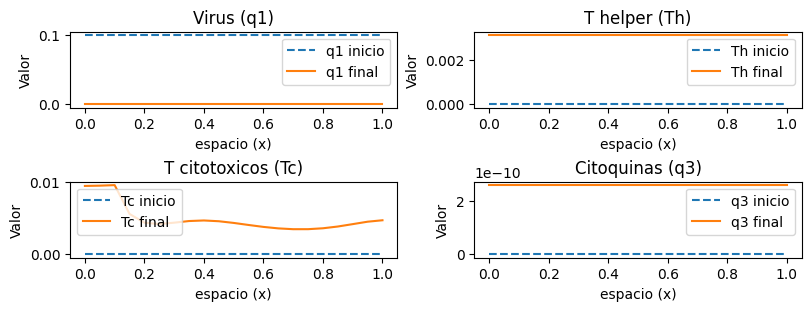

In [33]:
# Gráfica
fig, axs = plt.subplots(2, 2, figsize=(8, 3), constrained_layout=True)

axs[0,0].plot(x, q1[0,:], '--', label="q1 inicio")
axs[0,0].plot(x, q1[-1,:], label="q1 final")
axs[0,0].set_title("Virus (q1)")
axs[0,0].set_ylabel("Valor")
axs[0,0].legend()

axs[0,1].plot(x, Th[0,:], '--', label="Th inicio")
axs[0,1].plot(x, Th[-1,:], label="Th final")
axs[0,1].set_title("T helper (Th)")
axs[0,1].set_ylabel("Valor")
axs[0,1].legend()

axs[1,0].plot(x, Tc[0,:], '--', label="Tc inicio")
axs[1,0].plot(x, Tc[-1,:], label="Tc final")
axs[1,0].set_title("T citotoxicos (Tc)")
axs[1,0].set_ylabel("Valor")
axs[1,0].legend()

axs[1,1].plot(x, q3[0,:], '--', label="q3 inicio")
axs[1,1].plot(x, q3[-1,:], label="q3 final")
axs[1,1].set_title("Citoquinas (q3)")
axs[1,1].set_ylabel("Valor")
axs[1,1].legend()

for ax in axs.flat:
    ax.set_xlabel("espacio (x)")

# GUARDAR IMAGEN PNG A 300 DPI
fig.savefig(
    "analisis_espacial_1D_curado.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

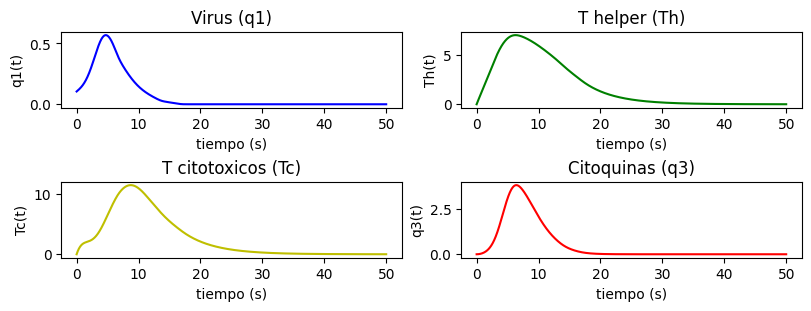

In [34]:
q1total = np.sum(q1, axis=1) * dx
Thtotal = np.sum(Th, axis=1) * dx
Tctotal = np.sum(Tc, axis=1) * dx
q3total = np.sum(q3, axis=1) * dx

fig, axs = plt.subplots(2,2,figsize=(8, 3), constrained_layout=True)

ax1, ax2, ax3, ax4 = axs[0,0], axs[0,1], axs[1,0], axs[1,1]

ax1.plot(t, q1total, 'b', label='q1(t)')
ax2.plot(t, Thtotal, 'g', label='Th(t)')
ax3.plot(t, Tctotal, 'y', label='Tc(t)')
ax4.plot(t, q3total, 'r', label='q3(t)')

ax1.set_title("Virus (q1)")
ax1.set_xlabel("tiempo (s)")
ax1.set_ylabel("q1(t)")

ax2.set_title("T helper (Th)")
ax2.set_xlabel("tiempo (s)")
ax2.set_ylabel("Th(t)")

ax3.set_title("T citotoxicos (Tc)")
ax3.set_xlabel("tiempo (s)")
ax3.set_ylabel("Tc(t)")

ax4.set_title("Citoquinas (q3)")
ax4.set_xlabel("tiempo (s)")
ax4.set_ylabel("q3(t)")

# GUARDAR IMAGEN PNG A 300 DPI
fig.savefig(
    "analisis_temporal_1D_curado.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

Text(0.5, 1.0, 'Evolución temporal de cada variable')

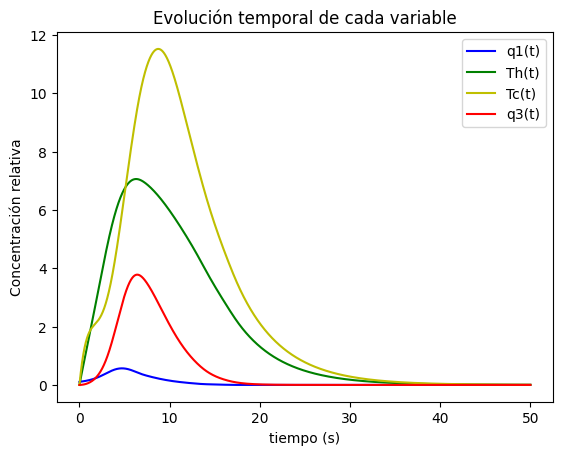

In [35]:
# Gráficas temporales 
plt.plot(t, q1total, 'b', label='q1(t)')
plt.plot(t, Thtotal, 'g', label='Th(t)')
plt.plot(t, Tctotal, 'y', label='Tc(t)')
plt.plot(t, q3total, 'r', label='q3(t)')

plt.xlabel("tiempo (s)")
plt.ylabel("Concentración relativa")
plt.legend(loc='upper right')
plt.title("Evolución temporal de cada variable")

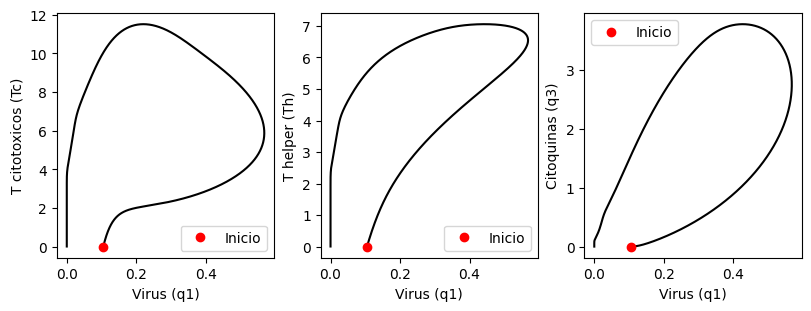

Text(0.5, 1.0, 'Fase espacio de cada variable')

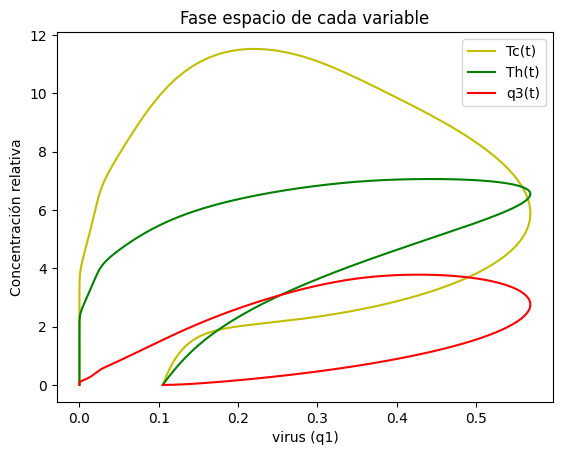

In [36]:
# Diagrama de fase 
fig, axs = plt.subplots(1, 3, figsize=(8, 3), constrained_layout=True)

axs[0].plot(q1total, Tctotal, 'k')
axs[0].plot(q1total[0], Tctotal[0], 'or', label="Inicio")
axs[0].set_xlabel("Virus (q1)")
axs[0].set_ylabel("T citotoxicos (Tc)")
axs[0].legend()

axs[1].plot(q1total, Thtotal, 'k')
axs[1].plot(q1total[0], Thtotal[0], 'or', label="Inicio")
axs[1].set_xlabel("Virus (q1)")
axs[1].set_ylabel("T helper (Th)")
axs[1].legend()

axs[2].plot(q1total, q3total, 'k')
axs[2].plot(q1total[0], q3total[0], 'or', label="Inicio")
axs[2].set_xlabel("Virus (q1)")
axs[2].set_ylabel("Citoquinas (q3)")
axs[2].legend() 

# GUARDAR IMAGEN PNG A 300 DPI
fig.savefig(
    "analisis_fase_1D_curado.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

# Diagrama de fase
plt.plot(q1total, Tctotal, 'y', label='Tc(t)')
plt.plot(q1total, Thtotal, 'g', label='Th(t)')
plt.plot(q1total, q3total, 'r', label='q3(t)')

plt.xlabel("virus (q1)")
plt.ylabel("Concentración relativa")
plt.legend(loc='upper right')
plt.title("Fase espacio de cada variable")
